# BÀI TẬP 1 - ANN: Nhận dạng ảnh CIFAR10
**Dataset:** CIFAR10 (built-in TensorFlow)
**Labels:** airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

In [1]:
# ==============================================================
# BƯỚC 1: NẠP THƯ VIỆN
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# ==============================================================
# BƯỚC 2: ĐỌC TẬP DỮ LIỆU CIFAR10
# ==============================================================
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape: ', X_test.shape)
print('y_test shape: ', y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 41s 0us/step
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape:  (10000, 32, 32, 3)
y_test shape:  (10000, 1)


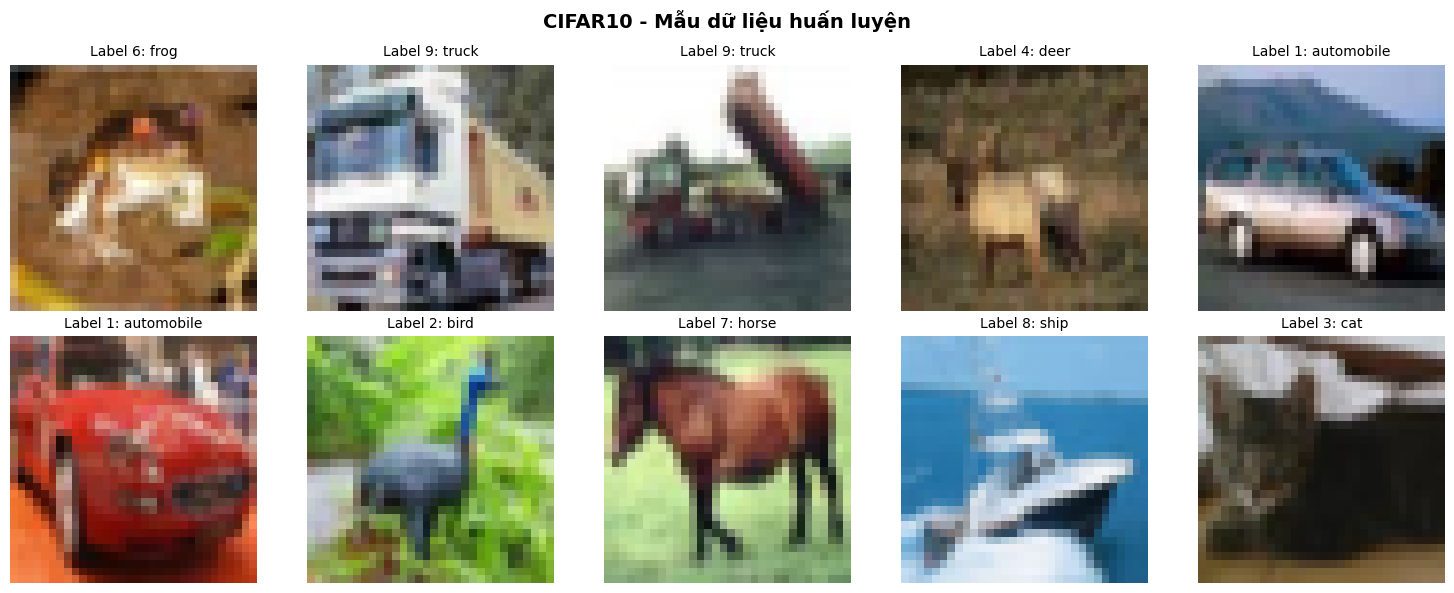

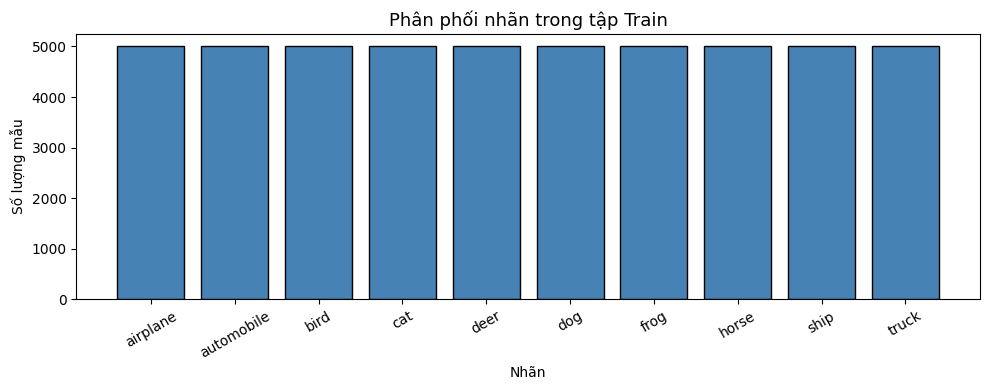

In [3]:
# ==============================================================
# BƯỚC 3: TRỰC QUAN HÓA DỮ LIỆU
# ==============================================================
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train[i])
    axes[i].set_title(f'Label {y_train[i][0]}: {class_names[y_train[i][0]]}', fontsize=10)
    axes[i].axis('off')
plt.suptitle('CIFAR10 - Mẫu dữ liệu huấn luyện', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Biểu đồ phân phối nhãn
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar([class_names[i] for i in unique], counts, color='steelblue', edgecolor='black')
plt.title('Phân phối nhãn trong tập Train', fontsize=13)
plt.xlabel('Nhãn')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [4]:
# ==============================================================
# BƯỚC 4: XỬ LÝ DỮ LIỆU
# ==============================================================
# Reshape từ 3D (32,32,3) -> 2D (3072,)
X_train_flat = X_train.reshape(X_train.shape[0], -1).astype('float32')
X_test_flat  = X_test.reshape(X_test.shape[0],  -1).astype('float32')

# Feature scaling về [0, 1]
X_train_flat = X_train_flat / 255.0
X_test_flat  = X_test_flat  / 255.0

# Flatten label
y_train_flat = y_train.flatten()
y_test_flat  = y_test.flatten()

print('X_train_flat shape:', X_train_flat.shape)
print('Số lớp:', len(np.unique(y_train_flat)))

X_train_flat shape: (50000, 3072)
Số lớp: 10


In [5]:
# ==============================================================
# BƯỚC 5: XÂY DỰNG MÔ HÌNH ANN
# ==============================================================
model = Sequential()

# Hidden layer 1
model.add(Dense(input_dim=X_train_flat.shape[1], units=512,
                kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.3))

# Hidden layer 2
model.add(Dense(units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.3))

# Output layer
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ==============================================================
# BƯỚC 6: HUẤN LUYỆN MÔ HÌNH
# ==============================================================
model_fit = model.fit(X_train_flat, y_train_flat,
                      validation_split=0.1,
                      epochs=20,
                      batch_size=128,
                      verbose=1)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.2853 - loss: 1.9555 - val_accuracy: 0.3456 - val_loss: 1.8005
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.3416 - loss: 1.8249 - val_accuracy: 0.3770 - val_loss: 1.7415
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.3616 - loss: 1.7687 - val_accuracy: 0.3932 - val_loss: 1.6896
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.3768 - loss: 1.7309 - val_accuracy: 0.4180 - val_loss: 1.6401
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.3861 - loss: 1.7039 - val_accuracy: 0.4284 - val_loss: 1.6089
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.3973 - loss: 1.6763 - val_accuracy: 0.4394 - val_loss: 1.5857
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.4009 - loss: 1.6602 - val_accuracy: 0.4406 - val_loss: 1.5791
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.4091 - loss: 1.6406 - 

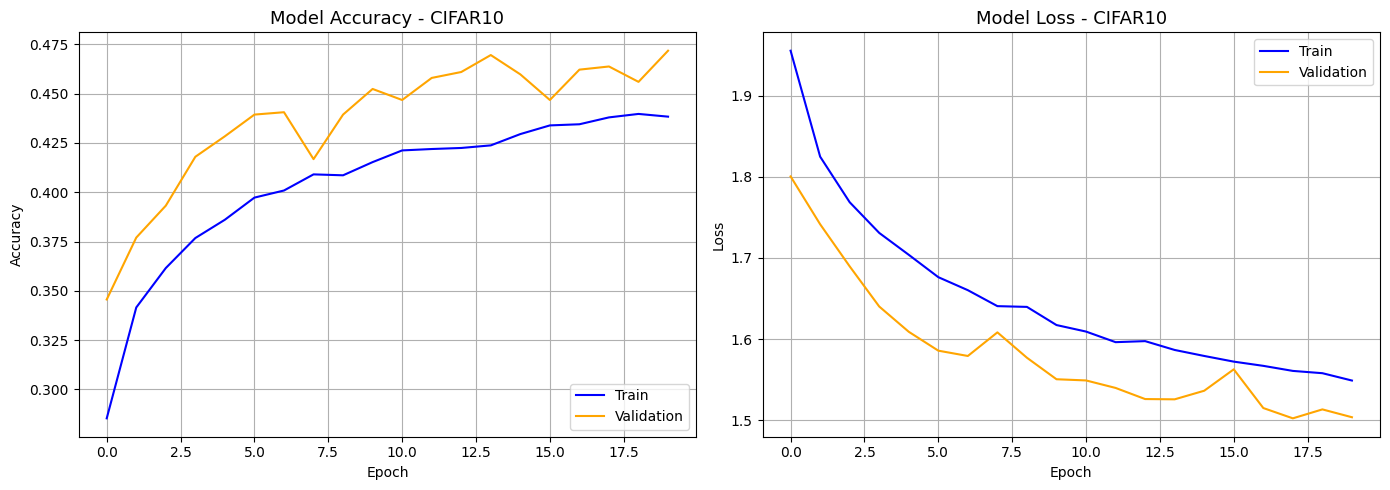

In [7]:
# ==============================================================
# BƯỚC 7: ĐÁNH GIÁ MÔ HÌNH - BIỂU ĐỒ ACCURACY & LOSS
# ==============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(model_fit.history['accuracy'], label='Train', color='blue')
axes[0].plot(model_fit.history['val_accuracy'], label='Validation', color='orange')
axes[0].set_title('Model Accuracy - CIFAR10', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True)

# Loss
axes[1].plot(model_fit.history['loss'], label='Train', color='blue')
axes[1].plot(model_fit.history['val_loss'], label='Validation', color='orange')
axes[1].set_title('Model Loss - CIFAR10', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

=== Classification Report ===
              precision    recall  f1-score   support

    airplane       0.59      0.46      0.51      1000
  automobile       0.50      0.68      0.58      1000
        bird       0.40      0.18      0.25      1000
         cat       0.34      0.30      0.32      1000
        deer       0.36      0.54      0.43      1000
         dog       0.44      0.33      0.38      1000
        frog       0.46      0.58      0.51      1000
       horse       0.56      0.50      0.53      1000
        ship       0.56      0.67      0.61      1000
       truck       0.53      0.49      0.51      1000

    accuracy                           0.47     10000
   macro avg       0.47      0.47      0.46     10000
weighted avg       0.47      0.47      0.46     10000



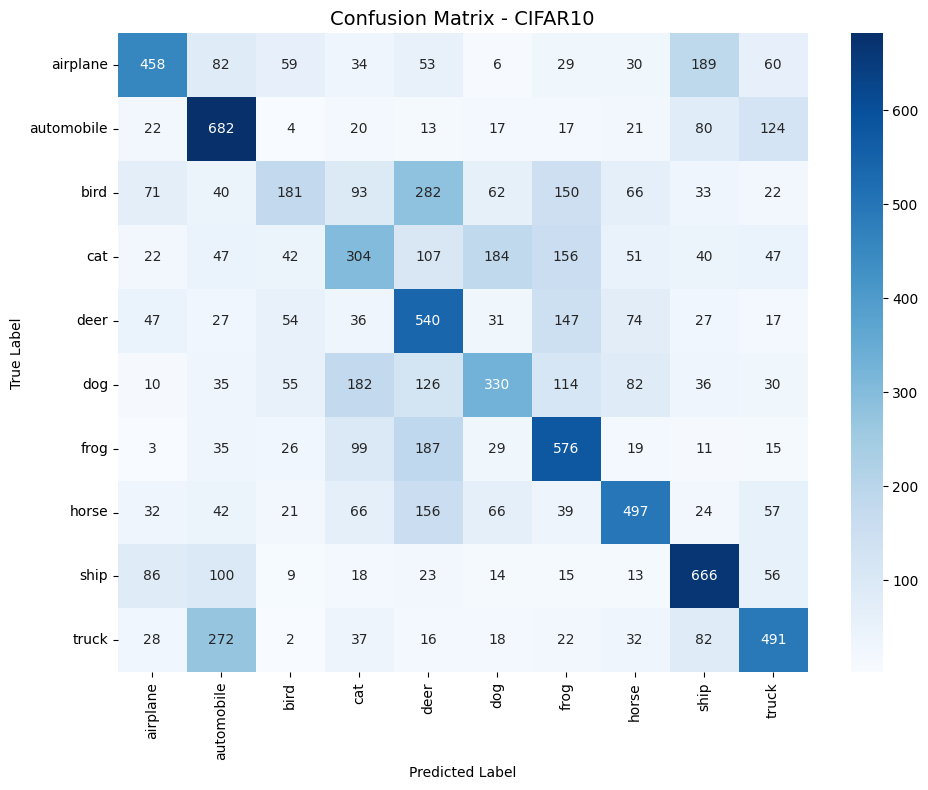


Test Accuracy: 0.4725 | Test Loss: 1.4911


In [8]:
# ==============================================================
# BƯỚC 8: CONFUSION MATRIX & CLASSIFICATION REPORT
# ==============================================================
y_pred = np.argmax(model.predict(X_test_flat), axis=1)

print('\n=== Classification Report ===')
print(classification_report(y_test_flat, y_pred, target_names=class_names))

cm = confusion_matrix(y_test_flat, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - CIFAR10', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

loss, acc = model.evaluate(X_test_flat, y_test_flat, verbose=0)
print(f'\nTest Accuracy: {acc:.4f} | Test Loss: {loss:.4f}')

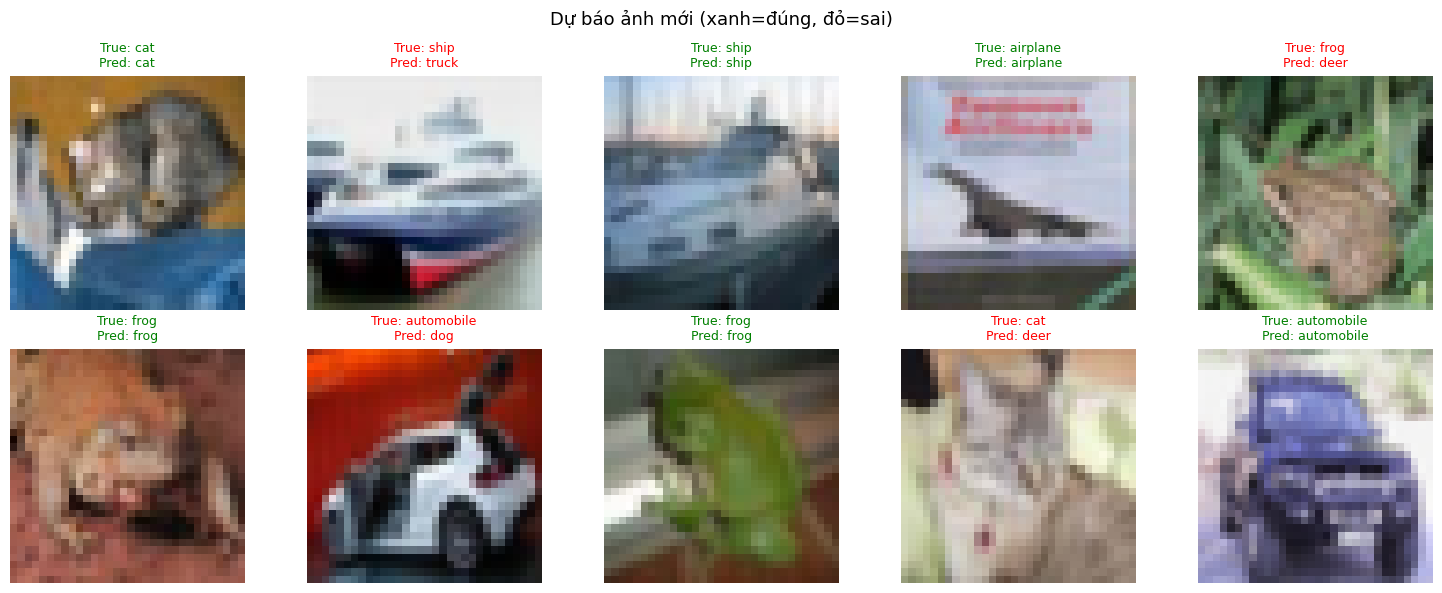

In [9]:
# ==============================================================
# BƯỚC 9: DỰ BÁO ẢNH MỚI
# ==============================================================
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    pred = np.argmax(model.predict(X_test_flat[i:i+1], verbose=0))
    true = y_test_flat[i]
    color = 'green' if pred == true else 'red'
    axes[i].imshow(X_test[i])
    axes[i].set_title(f'True: {class_names[true]}\nPred: {class_names[pred]}',
                      color=color, fontsize=9)
    axes[i].axis('off')
plt.suptitle('Dự báo ảnh mới (xanh=đúng, đỏ=sai)', fontsize=13)
plt.tight_layout()
plt.show()